# Revolut FAQ RAG Chatbot

A minimal single-turn RAG chatbot over Revolut help articles.

In [1]:
import asyncio
import json
import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import AsyncOpenAI
from tqdm import tqdm

# Add project root to path
import sys
project_root = Path.cwd().parent
while not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.config import (
    BASE_URL, EMBED_MODEL, STUDENT_MODEL, TOP_K,
    CONCURRENCY, MAX_ROWS, SEED
)
from src.rag import (
    get_client,
    embed_texts, build_corpus_embeddings, retrieve as retrieve_from_emb
)
from src.generate_queries import generate_queries_with_resume
from src.vibe_check import validate_queries_with_resume
from src.judges import judge_with_resume

load_dotenv(dotenv_path=project_root / ".env")

DATA_DIR = project_root / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"

print(f"Configuration:")
print(f"  BASE_URL: {BASE_URL}")
print(f"  EMBED_MODEL: {EMBED_MODEL}")
print(f"  STUDENT_MODEL: {STUDENT_MODEL}")
print(f"  TOP_K: {TOP_K}")
print(f"  CONCURRENCY: {CONCURRENCY}")
print(f"  MAX_ROWS: {MAX_ROWS}")
print(f"  SEED: {SEED}")

Configuration:
  BASE_URL: https://api.openai.com/v1
  EMBED_MODEL: text-embedding-3-small
  STUDENT_MODEL: gpt-4o-mini
  TOP_K: 4
  CONCURRENCY: 16
  MAX_ROWS: None
  SEED: 42


## 1. Load articles

In [2]:
ARTICLES_PATH = DATA_DIR / "revolut_help_articles.jsonl"

articles = [json.loads(line) for line in ARTICLES_PATH.read_text().strip().split("\n")]
print(f"Loaded {len(articles)} articles")
print(f"Example: {articles[0]['title']}")

Loaded 786 articles
Example: How can I see my cashflow analytics?


## 2. Embed all articles

In [3]:
corpus_embeddings, articles = await build_corpus_embeddings()
print(f"Embeddings shape: {corpus_embeddings.shape}")

Loading cached embeddings from /Users/veniamin/Projects/chatbot-evals-ai/data/outputs/corpus_emb.npz
Embeddings shape: (786, 1536)


## 3. Retrieval

In [4]:
async def retrieve(query_text: str, k: int = TOP_K):
    """Retrieve top-k articles for a query."""
    client = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"), base_url=BASE_URL)
    response = await client.embeddings.create(model=EMBED_MODEL, input=query_text)
    query_emb = np.array(response.data[0].embedding)
    
    return retrieve_from_emb(query_emb, corpus_embeddings, articles, k)

print("retrieve() function defined")

retrieve() function defined


## 4. Single-turn chat

In [5]:
SYSTEM_PROMPT = (
    "You are a Revolut customer support assistant. "
    "Answer the user's question using ONLY the provided help articles. "
    "If the answer is not in the articles, say you don't know. "
    "Be concise and reference steps from the articles when relevant."
)

async def ask(query: str) -> tuple[str, list]:
    """Answer a query using RAG."""
    retrieved = await retrieve(query)
    
    context = "\n\n".join([
        f"Article: {r['title']}\n{r['content']}"
        for r in retrieved
    ])
    
    prompt = f"""{SYSTEM_PROMPT}

Customer question:
{query}

Relevant articles:
{context}

Answer:"""
    
    client = get_client()
    response = await client.chat.completions.create(
        model=STUDENT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=600
    )
    
    return response.choices[0].message.content.strip(), retrieved

print("ask() function defined")

ask() function defined


## 5. Try it

In [6]:
question = "What's the best way to transfer money to a Monzo account?"
answer, retrieved = await ask(question)

print("Q:", question)
print("\nA:", answer)
print("\nRetrieved articles:")
for rank, r in enumerate(retrieved, start=1):
    print(f"  {rank}. {r['title']} (score: {r['score']:.3f}")

Q: What's the best way to transfer money to a Monzo account?

A: To transfer money to a Monzo account, you can use a regular bank transfer or an easy bank transfer from your Revolut account. 

1. **Regular Bank Transfer**: Share your Revolut account details with your external bank and initiate the transfer through them. You can track the expected arrival date using the incoming transfer tracker.

2. **Easy Bank Transfer**: 
   - Go to 'Home' on the bottom menu.
   - Tap 'Add money'.
   - Enter the amount and select 'Easy bank transfer' as your payment method.
   - Approve the transfer in your external bank's app or website.

For more details on the easy bank transfer process, refer to the article on adding money with an easy bank transfer.

Retrieved articles:
  1. Add money with a bank transfer (score: 0.510
  2. Receiving money to my Revolut card (score: 0.504
  3. Add money with an easy bank transfer (score: 0.501
  4. How do I add funds to my Pro account? (score: 0.500


## 6. Evaluate Synthetic Dataset

Run every generated query through the RAG assistant and save both the answer and the retrieved context.

1500 generated -> 1500 (100%)


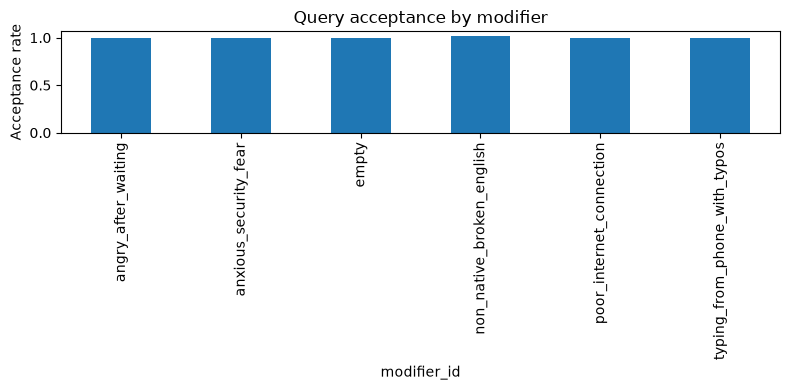

Loaded 1500 synthetic queries
                 persona                         script  \
0  uk_freelance_designer         verify_identity_failed   
1  uk_freelance_designer  pending_verification_too_long   
2  uk_freelance_designer        card_not_working_abroad   
3  uk_freelance_designer           virtual_card_missing   
4  uk_freelance_designer          apple_pay_not_working   

                    modifier  \
0  non_native_broken_english   
1  non_native_broken_english   
2  non_native_broken_english   
3  non_native_broken_english   
4  non_native_broken_english   

                                               query  
0  Hello, I submitted my documents for verify but...  
1  I finish verification 3 days ago but my accoun...  
2  My card not working in Thailand. I no change s...  
3  Hi, I need help. I want to make virtual card f...  
4  Hello, I try add my Revolut card to Apple Pay ...  


In [7]:
# Load validated queries
validated_file = OUTPUTS_DIR / "validated_queries.csv"
synthetic_file = OUTPUTS_DIR / "synthetic_queries.csv"

if validated_file.exists():
    synthetic_df = pd.read_csv(synthetic_file)
    validated_df = pd.read_csv(validated_file)
    
    generated = len(synthetic_df)
    validated = len(validated_df)
    acceptance_rate = validated / generated
    
    print(f"{generated} generated -> {validated} ({acceptance_rate:.0%})")
    
    # Acceptance by modifier (single barplot)
    modifier_rates = validated_df.groupby("modifier_id").size() / synthetic_df.groupby("modifier_id").size()
    plt.figure(figsize=(8, 4))
    modifier_rates.plot(kind="bar")
    plt.ylabel("Acceptance rate")
    plt.title("Query acceptance by modifier")
    plt.tight_layout()
    plt.show()
    
    # Display with renamed columns
    display_df = validated_df.rename(columns={
        'persona_id': 'persona',
        'problem_id': 'script',
        'modifier_id': 'modifier'
    })[['persona', 'script', 'modifier', 'query']]
    
    print(f"Loaded {len(display_df)} synthetic queries")
    print(display_df.head())
else:
    print("Validated queries not found - run vibe check first")

In [8]:
# Run RAG over dataset
RAG_OUTPUT_PATH = OUTPUTS_DIR / "rag_outputs.csv"

if RAG_OUTPUT_PATH.exists():
    existing = pd.read_csv(RAG_OUTPUT_PATH)
    print(f"RAG resume: {len(existing)} done, 0 missing")
    rag_df = existing
else:
    print("RAG resume: 0 done, all missing")
    from src.rag import run_rag
    rag_df = await run_rag(validated_df)

# Display with renamed columns
display_df = rag_df.rename(columns={
    'persona_id': 'persona',
    'problem_id': 'script',
    'modifier_id': 'modifier'
})[['persona', 'script', 'modifier', 'query', 'answer']]

# Add retrieved_articles column (article titles joined with " | ")
display_df['retrieved_articles'] = rag_df['retrieved_titles'].apply(
    lambda x: ' | '.join(eval(x)) if isinstance(x, str) else ' | '.join(x)
)

print(display_df.head())

RAG resume: 1080 done, 0 missing
                 persona                  script  \
0  uk_freelance_designer  transfer_pending_stuck   
1  uk_freelance_designer  transfer_pending_stuck   
2  uk_freelance_designer  transfer_pending_stuck   
3  uk_freelance_designer  transfer_pending_stuck   
4  uk_freelance_designer  transfer_pending_stuck   

                       modifier  \
0                         empty   
1      poor_internet_connection   
2         anxious_security_fear   
3           angry_after_waiting   
4  typing_from_phone_with_typos   

                                               query  \
0  Hi there, I've sent some money to my mate two ...   
1  Hey, I sent money to my mate two days ago and ...   
2  I sent money to my mate two days ago and it’s ...   
3  I've sent money to my mate two days ago and it...   
4  Hey, I sent some cash to my mate two days ago ...   

                                              answer  \
0  Your transfer may be pending for several reaso.

## 7. LLM-as-a-Judge Evaluation

Evaluate each RAG answer with the judge metrics and save the final table.

In [9]:
# Run judges
JUDGE_OUTPUT_PATH = OUTPUTS_DIR / "eval_results.csv"

METRIC_COLS = ['relevance_passed', 'groundedness_passed', 'completeness_passed', 
               'actionability_passed', 'tone_empathy_passed', 'safety_compliance_passed']

if JUDGE_OUTPUT_PATH.exists():
    existing = pd.read_csv(JUDGE_OUTPUT_PATH)
    print(f"Judge resume: {len(existing)} done, 0 missing")
    eval_df = existing
else:
    print("Judge resume: 0 done, all missing")
    await judge_with_resume(RAG_OUTPUT_PATH, JUDGE_OUTPUT_PATH)
    eval_df = pd.read_csv(JUDGE_OUTPUT_PATH)

print(eval_df.head())

Judge resume: 1080 done, 0 missing
              persona_id                     problem_id  \
0  uk_freelance_designer  pending_verification_too_long   
1  uk_freelance_designer  pending_verification_too_long   
2  uk_freelance_designer  pending_verification_too_long   
3  uk_freelance_designer  pending_verification_too_long   
4  uk_freelance_designer        card_not_working_abroad   

                    modifier_id  \
0                         empty   
1         anxious_security_fear   
2           angry_after_waiting   
3  typing_from_phone_with_typos   
4         anxious_security_fear   

                                               query  looks_human_mobile  \
0  Hi there, I completed my verification 3 days a...                True   
1  Hi there, I've completed my verification three...                True   
2  I've completed my verification 3 days ago and ...                True   
3  Hey mate, I did the verification thing 3 days ...                True   
4  My card just got

In [10]:
# Overall pass rates
pass_rates = eval_df[METRIC_COLS].mean().sort_values(ascending=False)
print("Overall LLM-as-a-judge pass rates:")
for metric, rate in pass_rates.items():
    print(f"  {metric.replace('_passed', '')}: {rate:.1%}")

Overall LLM-as-a-judge pass rates:
  relevance: 78.2%
  completeness: 74.0%
  actionability: 67.8%
  safety_compliance: 38.1%
  groundedness: 19.3%
  tone_empathy: 0.4%


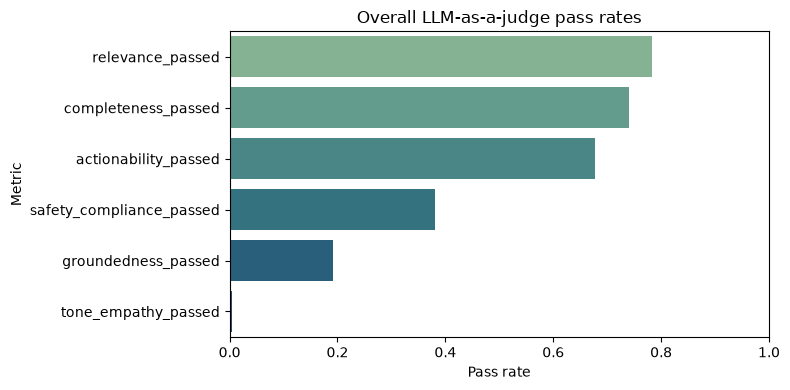

In [11]:
# Pass rate barplot
plt.figure(figsize=(8, 4))
sns.barplot(
    x=pass_rates.values,
    y=pass_rates.index,
    hue=pass_rates.index,
    palette="crest",
    legend=False,
)
plt.xlim(0, 1)
plt.xlabel("Pass rate")
plt.ylabel("Metric")
plt.title("Overall LLM-as-a-judge pass rates")
plt.tight_layout()
plt.show()

## 8. Metric Correlations and Distributions

Use the completed evaluation table to inspect metric pass rates, metric correlations, and where failures concentrate across seed aliases.

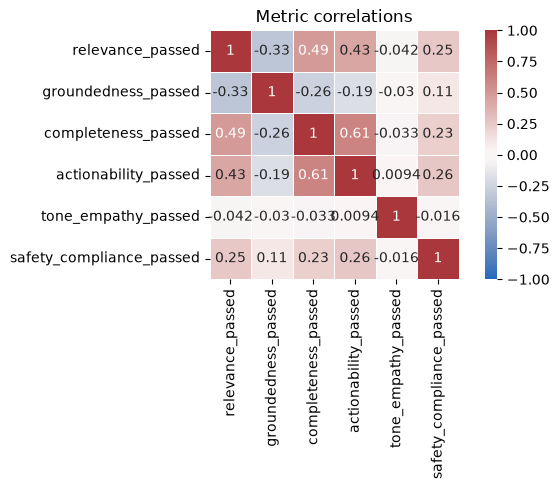

In [12]:
# Metric correlations
corr = eval_df[METRIC_COLS].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    linewidths=0.5,
)
plt.title("Metric correlations")
plt.tight_layout()
plt.show()

### Metric Distribution by Seed Alias

Each cell is the share of answers that passed a metric for that seed alias.

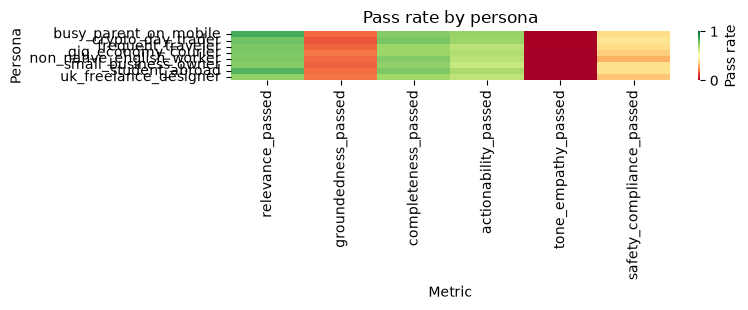

In [13]:
# Pass rate by persona
persona_summary = eval_df.groupby('persona_id')[METRIC_COLS].mean()

plt.figure(figsize=(8, len(persona_summary) * 0.4))
sns.heatmap(persona_summary, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.xlabel("Metric")
plt.ylabel("Persona")
plt.title("Pass rate by persona")
plt.tight_layout()
plt.show()

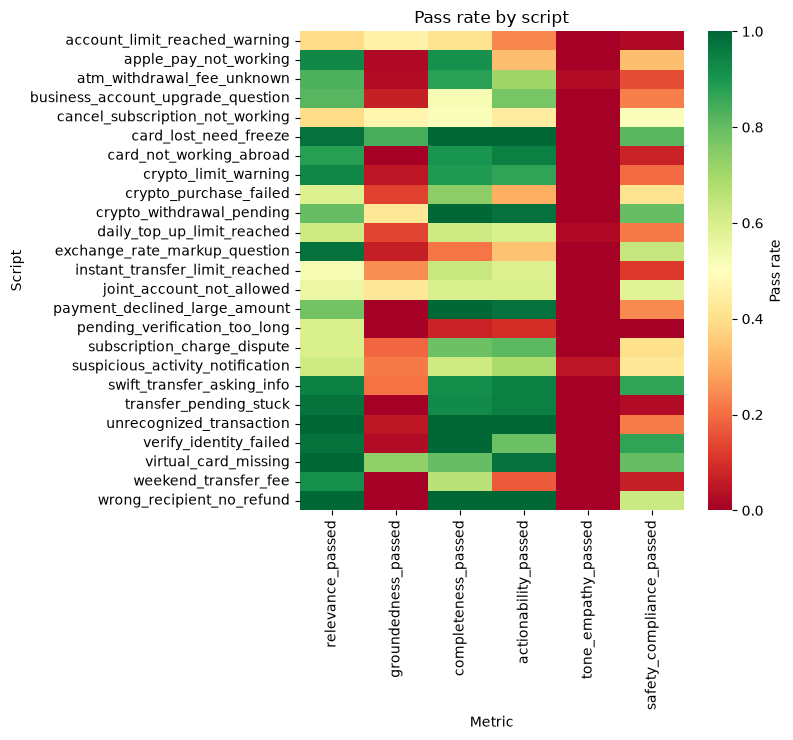

In [14]:
# Pass rate by script (problem)
script_summary = eval_df.groupby('problem_id')[METRIC_COLS].mean()

plt.figure(figsize=(8, len(script_summary) * 0.3))
sns.heatmap(script_summary, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.xlabel("Metric")
plt.ylabel("Script")
plt.title("Pass rate by script")
plt.tight_layout()
plt.show()

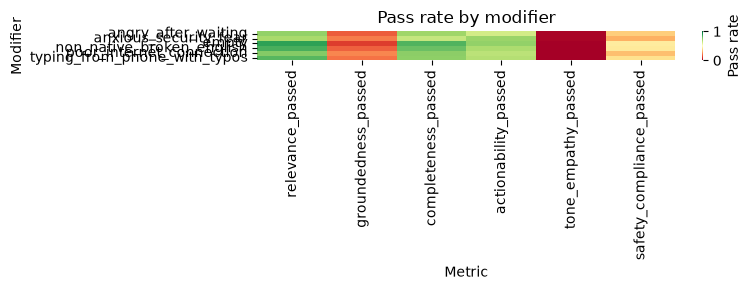

In [15]:
# Pass rate by modifier
modifier_summary = eval_df.groupby('modifier_id')[METRIC_COLS].mean()

plt.figure(figsize=(8, len(modifier_summary) * 0.5))
sns.heatmap(modifier_summary, cmap="RdYlGn", vmin=0, vmax=1, cbar_kws={'label': 'Pass rate'})
plt.xlabel("Metric")
plt.ylabel("Modifier")
plt.title("Pass rate by modifier")
plt.tight_layout()
plt.show()

## Conclusions

Overall RAG performance: relevance 78.2%, groundedness 19.3%, completeness 74.0%, actionability 67.8%, tone_empathy 0.4%, safety 38.1%.

Groundedness is the primary failure mode—answers often invent details not in retrieved articles.

The tone_empathy metric (0.4%) suggests our judges need calibration or the prompt needs empathy guidance.

See Part 2 (GEPA optimization) for automated prompt improvement against gold labels.